<a href="https://colab.research.google.com/github/shaloy-lewis/Car_Price_Prediction/blob/main/RR_Car_Price_Prediction_Shaloy_Lewis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **1.1.1**
Load the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/Upgrad/datasets/Car_Price_Prediction/Car_Price_data.csv')

In [ ]:
df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [ ]:
df.shape

(15915, 23)

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [ ]:
# Find the proportion of missing values in each column and handle if found
df.isna().sum()

,0
make_model,0
body_type,0
price,0
vat,0
km,0
Type,0
Fuel,0
Gears,0
Comfort_Convenience,0
Entertainment_Media,0


In [ ]:
df['cons_comb'].value_counts()

,count
cons_comb,
4.00,1020
5.60,963
5.40,900
5.00,810
4.70,766
...,...
8.10,2
5.45,2
4.30,1


In [ ]:
TARGET = ['price']
NUM_FEATURES = ['km', 'hp_kW', 'age', 'Previous_Owners', 'Displacement_cc', 'Weight_kg', 'cons_comb']
CAT_FEATURES = ['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security', 'Inspection_new', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

In [ ]:
df.columns

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'Type', 'Fuel',
       'Gears', 'Comfort_Convenience', 'Entertainment_Media', 'Extras',
       'Safety_Security', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new',
       'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Displacement_cc',
       'Weight_kg', 'Drive_chain', 'cons_comb'],
      dtype='object')

In [ ]:
len(NUM_FEATURES) + len(CAT_FEATURES) + len(TARGET) == df.shape[1]

True

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

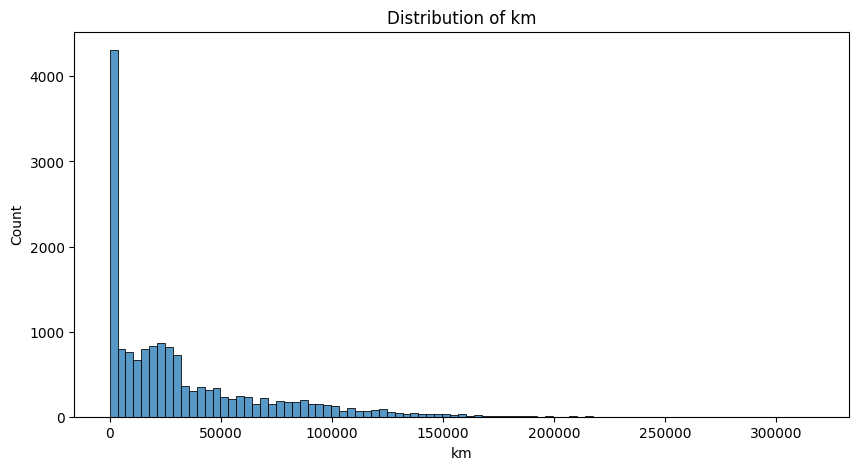

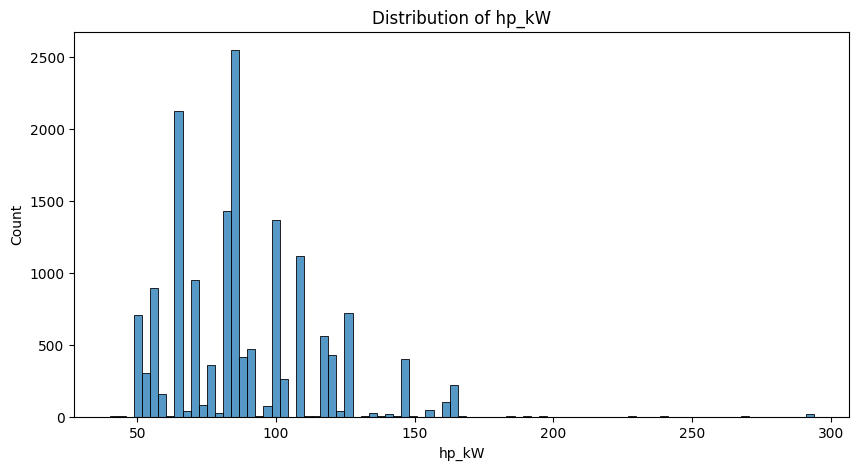

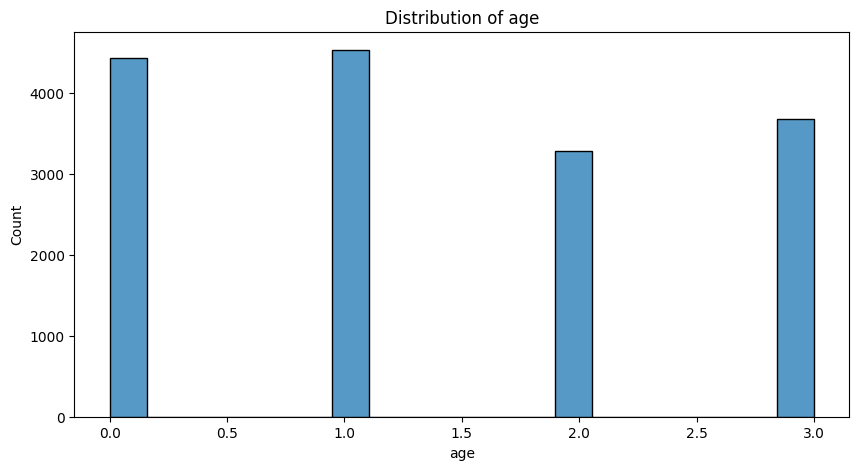

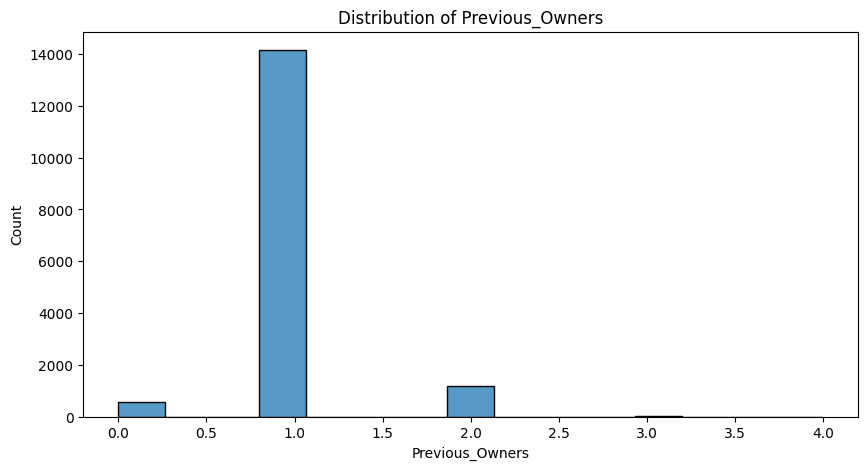

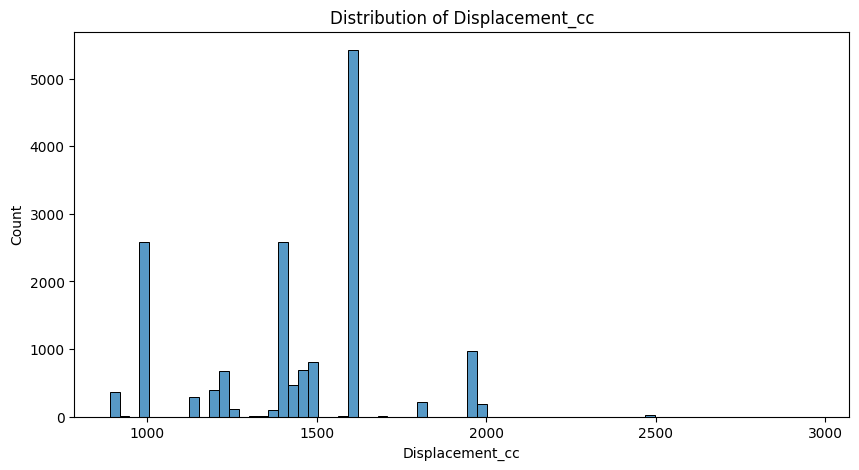

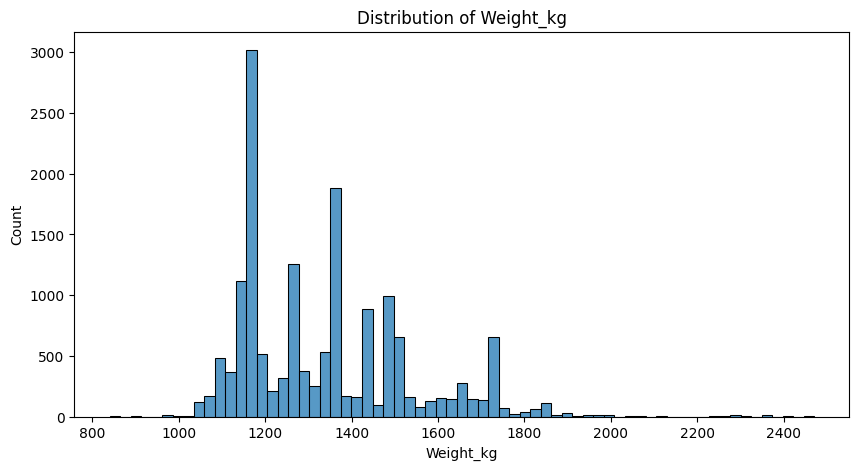

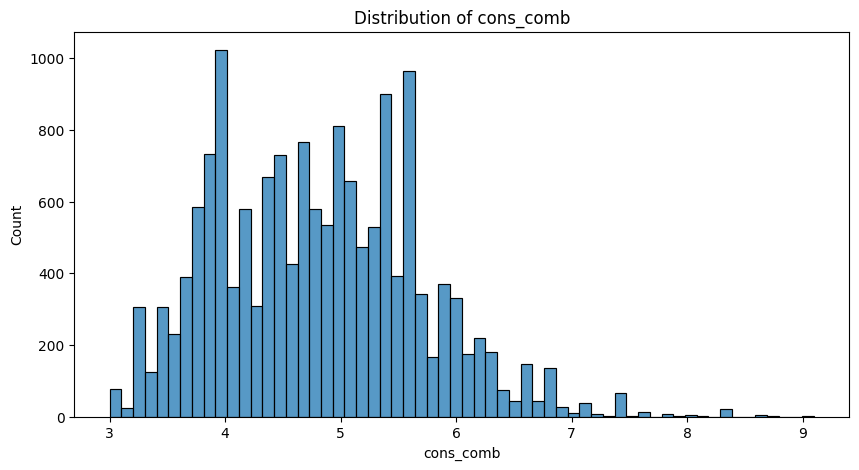

In [ ]:
# Identify numerical features and plot histograms
for feature in NUM_FEATURES:
  plt.figure(figsize=(10,5))
  sns.histplot(df[feature])
  plt.title(f'Distribution of {feature}')
  plt.show()

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

In [ ]:
for feature in CAT_FEATURES:
  print(f'Unique values in {feature}: {df[feature].nunique()}')

Unique values in make_model: 9
Unique values in body_type: 8
Unique values in vat: 2
Unique values in Type: 5
Unique values in Fuel: 4
Unique values in Gears: 4
Unique values in Comfort_Convenience: 6196
Unique values in Entertainment_Media: 346
Unique values in Extras: 659
Unique values in Safety_Security: 4442
Unique values in Inspection_new: 2
Unique values in Paint_Type: 3
Unique values in Upholstery_type: 2
Unique values in Gearing_Type: 3
Unique values in Drive_chain: 3


**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

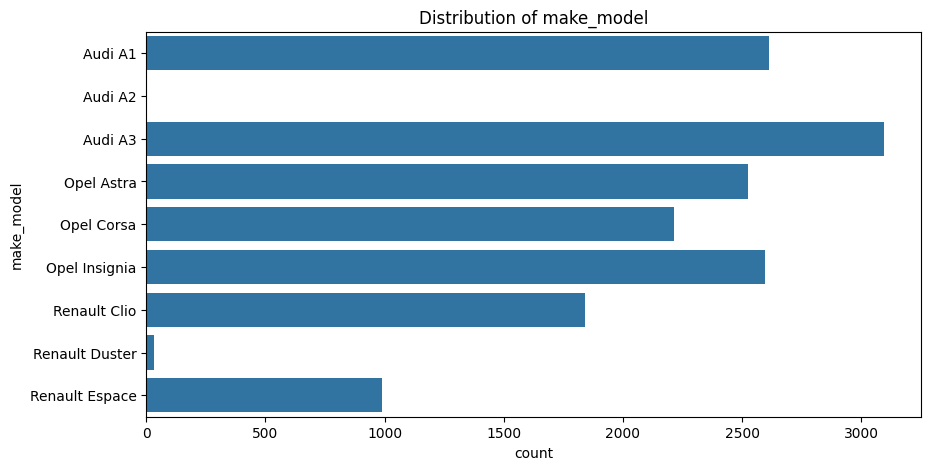

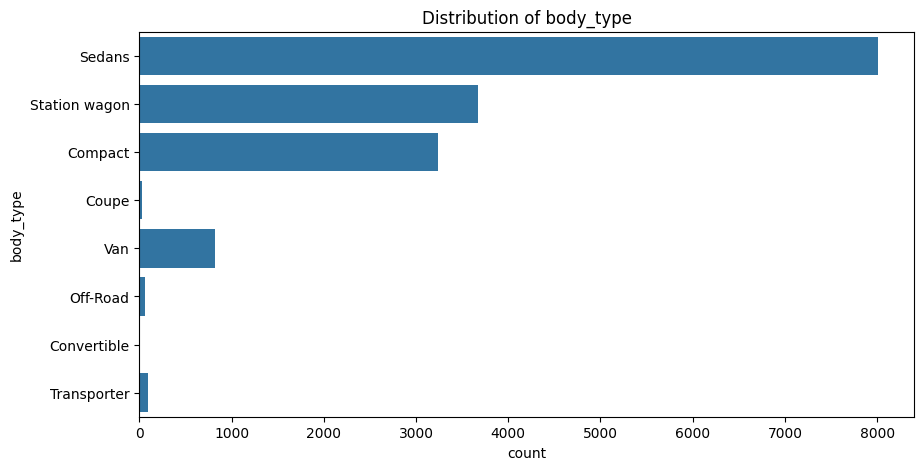

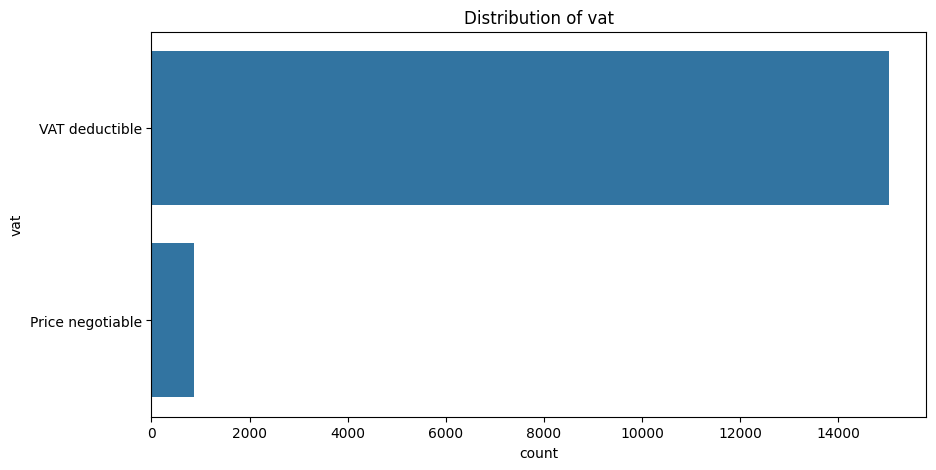

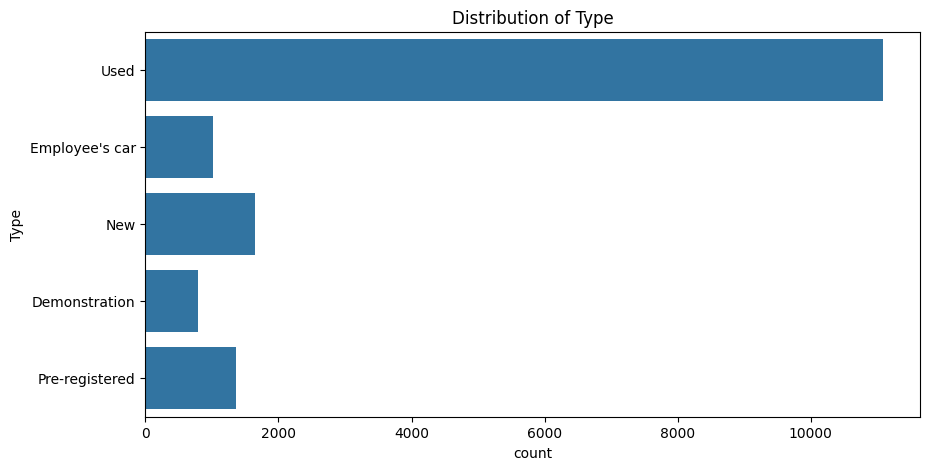

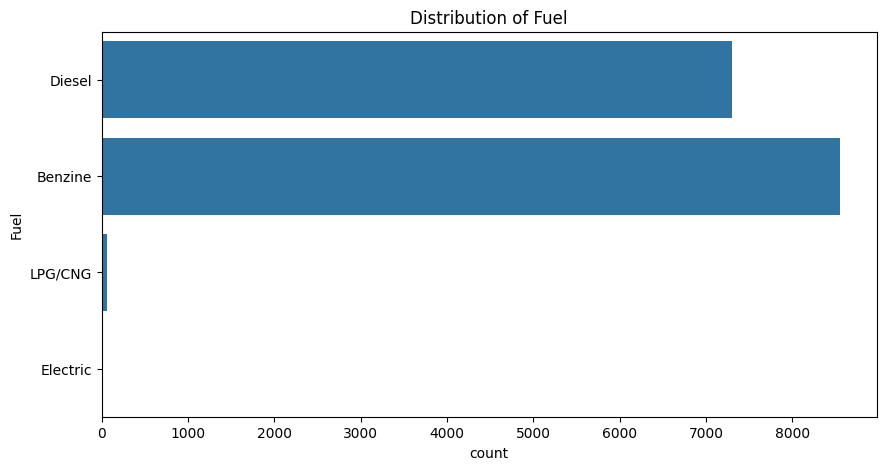

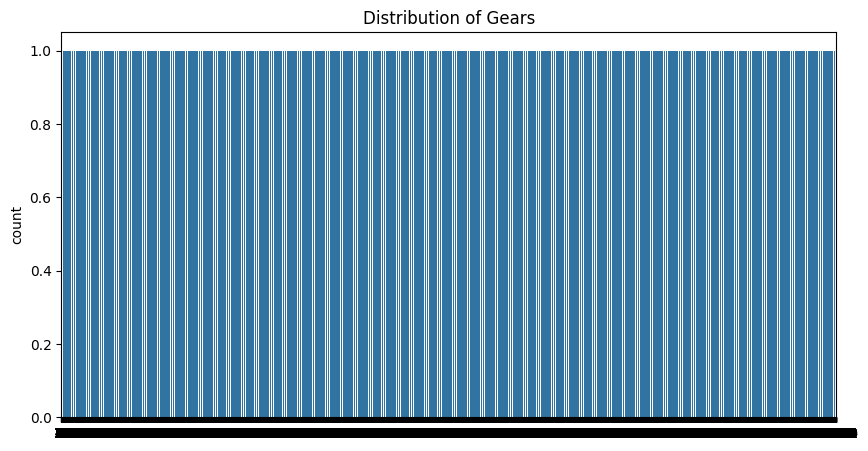

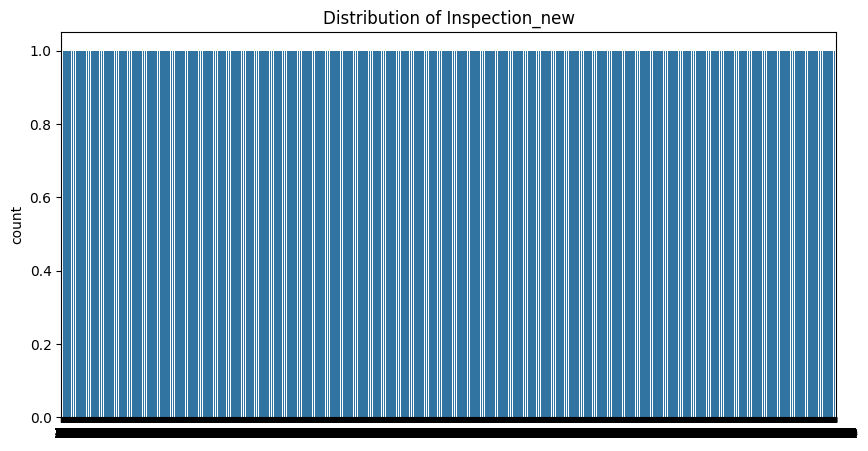

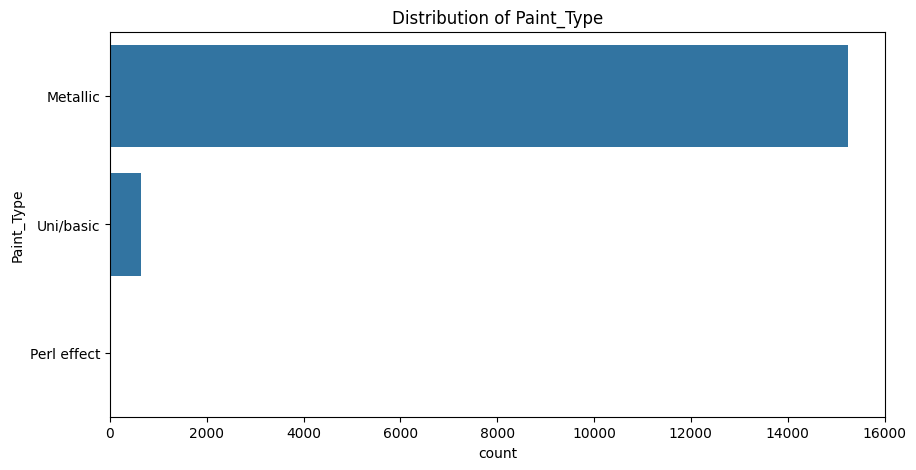

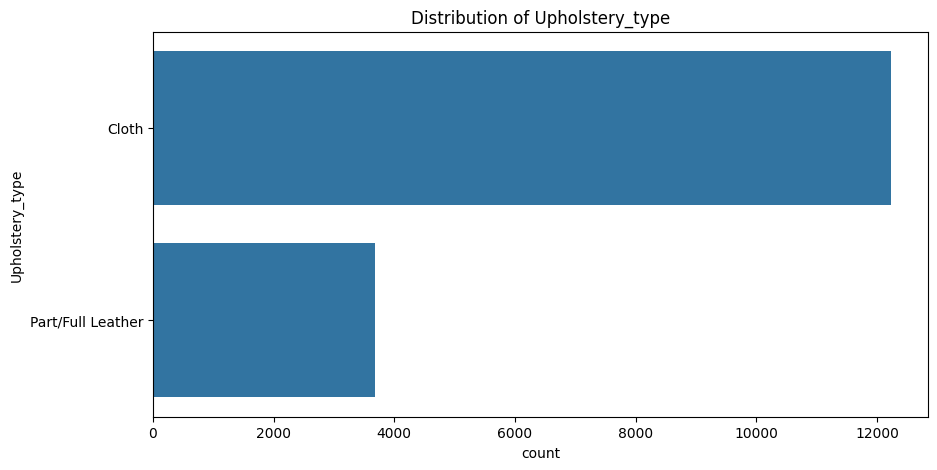

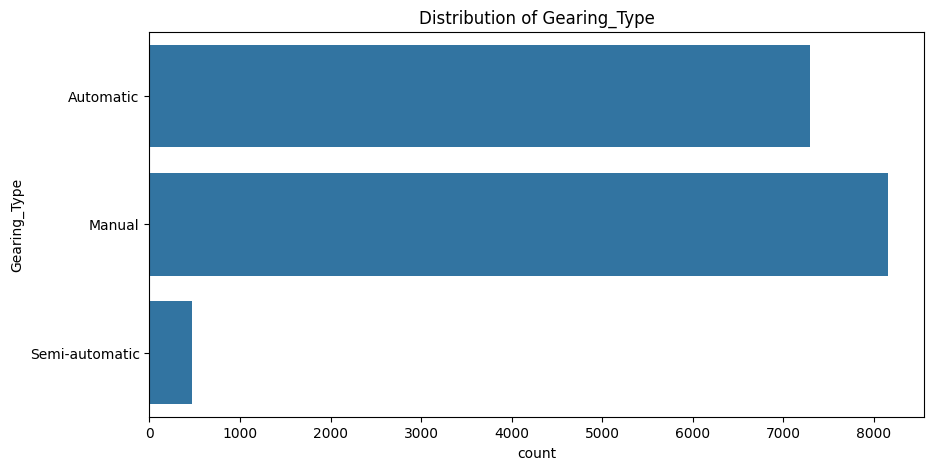

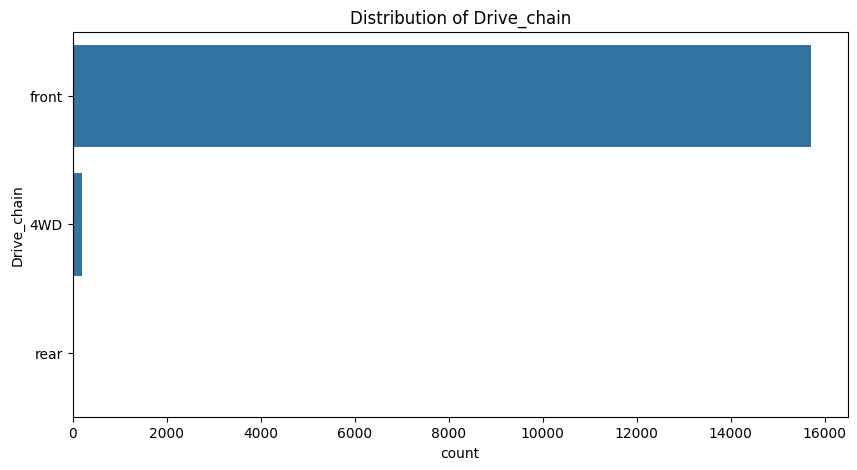

In [ ]:
# Identify categorical columns and check their frequency distributions
for feature in CAT_FEATURES:
  if df[feature].nunique() < 10:
    plt.figure(figsize=(10,5))
    sns.countplot(df[feature])
    plt.title(f'Distribution of {feature}')
    plt.show()


#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [ ]:
# Fix columns as needed



#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

In [ ]:
# Plot histograms for target feature



**The target variable seems to be skewed. Perform suitable transformation on the target.**

In [ ]:
# Transform the target feature



### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

In [ ]:
# Visualise correlation



#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

In [ ]:
# Comparing average values of target for different categories



### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

In [ ]:
# Outliers present in each column



#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [ ]:
# Handle outliers


### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [ ]:
# Fix/create columns as needed



#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [ ]:
# Check unique values in each feature spec column



Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [ ]:
# Drop features from df



#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [ ]:
# Encode features



#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [ ]:
# Split data


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [ ]:
# Scale features



## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [ ]:
# Initialise and train model


In [ ]:
# Evaluate the model's performance



#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

In [ ]:
# Linearity check: Plot residuals vs fitted values



Check normality in residual distribution

In [ ]:
# Check the normality of residuals by plotting their distribution



Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [ ]:
# Check for multicollinearity and handle



### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Ridge regularisation



#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Applying Ridge regression



In [ ]:
# Plot train and test scores against alpha



Find the best alpha value.

In [ ]:
# Best alpha value



# Best score (negative MAE)



We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# Take a smaller range of alpha to test



In [ ]:
# Applying Ridge regression



Plot the error-alpha graph again and find the actual optimal value for alpha.

In [ ]:
# Plot train and test scores against alpha



# Best alpha value



# Best score (negative MAE)



In [ ]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model



In [ ]:
# Show the coefficients for each feature



In [ ]:
# Evaluate the Ridge model on the test data



### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Lasso regularisation



#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Initialise Lasso regression model



In [ ]:
# Plot train and test scores against alpha



In [ ]:
# Best alpha value


# Best score (negative MAE)



#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# List of alphas to tune for Lasso regularization



In [ ]:
# Tuning Lasso hyperparameters



In [ ]:
# Plot train and test scores against alpha



In [ ]:
# Best alpha value


# Best score (negative MAE)



In [ ]:
# Set best alpha for Lasso regression


# Fit the Lasso model on scaled training data
# Get the coefficients of the fitted model



In [ ]:
# Check the coefficients for each feature



In [ ]:
# Evaluate the Lasso model on the test data



### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [ ]:
# Compare metrics for each model



#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [ ]:
# Compare highest coefficients and coefficients of eliminated features



## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>